In [106]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [107]:
import torch
import json
import os
from torch_geometric.nn import global_mean_pool
import src.global_config as global_cfg
import src.stats.config as cfg
import src.gnn.config as ecfg
import src.gnn.model as sage
import src.gnn.data_loader as gnnDataLoader
import src.gnn.train as train
import src.gnn.pipeline as pipeline
import src.gnn.analysis as eanalysis
import src.gnn.visualization as eviz
import src.stats.analysis as stat_analysis
import src.stats.visualization as stat_viz

In [108]:
with open("./Data/BN/network_2003.json", "r") as f:
    raw_json = json.load(f)
feature_mode = ecfg.FEATURE_MODE
snapshot_2003 = gnnDataLoader.json_to_pyg_data(raw_json, feature_mode=feature_mode)
print(f"Snapshot creado: {snapshot_2003}")
print(f"Nodos: {snapshot_2003.num_nodes}, Features: {snapshot_2003.num_node_features}")

Snapshot creado: Data(x=[397, 1], edge_index=[2, 396], edge_attr=[396, 1])
Nodos: 397, Features: 1


In [109]:
data = snapshot_2003
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)
data = data.to(device)

Usando dispositivo: cpu


In [110]:


model = sage.GraphSAGEEncoder(ecfg.IN_CHANNELS, ecfg.HIDDEN_CHANNELS, ecfg.OUT_CHANNELS, ecfg.DROPOUT_RATE).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=ecfg.LR_INITIAL, weight_decay=ecfg.WEIGHT_DECAY)
criterion = torch.nn.BCEWithLogitsLoss()

In [111]:
trained_model = train.train_linkpred(model, data, optimizer,  criterion, device, epochs=200)
trained_model.eval()
with torch.no_grad():
    z = trained_model(data.x, data.edge_index)  # [num_nodes, out_channels]

embeddings = z.cpu().numpy()
print("dimension de embeddings:", embeddings.shape)  # (num_nodes, out_channels)
print(embeddings[0])

items = raw_json["network"]["items"]
clusters = [node.get("cluster", -1) for node in items]  # lista de clusters


Epoch 001 | Loss: 0.7800
Epoch 020 | Loss: 0.4447
Epoch 040 | Loss: 0.4066
Epoch 060 | Loss: 0.3935
Epoch 080 | Loss: 0.3904
Epoch 100 | Loss: 0.3754
Epoch 120 | Loss: 0.3790
Epoch 140 | Loss: 0.3758
Epoch 160 | Loss: 0.3633
Epoch 180 | Loss: 0.3622
Epoch 200 | Loss: 0.3662
dimension de embeddings: (397, 8)
[-10.390689     6.342993     0.14538166   7.308442    -9.171463
 -10.94662      7.3166533   -9.962908  ]


In [112]:

# z ya existe, NO usamos z_nodes aquí
ego_mask = gnnDataLoader.get_ego_mask(raw_json).to(device)

# Filtrar solo alters
z_alters = z[ego_mask]

# Nuevo batch: todos los alters pertenecen al mismo grafo
batch_alters = torch.zeros(z_alters.size(0), dtype=torch.long, device=device)

graph_embedding = global_mean_pool(z_alters, batch_alters)

print("Dimension del embedding del grafo (sin ego):", graph_embedding.shape)
print(graph_embedding)


# Crear el vector batch (todos los nodos tienen la etiqueta 0 porque es un solo grafo)
# z es la matriz de embeddings de todos los nodos, es de la forma [No.Nodos, out_channels]
print(z.shape)
#batch = torch.zeros(data.num_nodes, dtype=torch.long, device=device)

# Hacemos el pooling usando los embeddings de nodos ya entrenados (z)
# El pooling hace un "promedio" en base al tamaño del batch, en nuestro caso
# al poner batch como un tensor llenos de 0's, entonces promedia todos aquellos que tengan como indice 0 (todos los nodos)
#Devuelve una matriz de [1, 16], "comprime" todos los embeddings a uno solo
#graph_embedding = global_mean_pool(z, batch)
print("Dimension del embedding del grafo:", graph_embedding.shape)
print(graph_embedding)

Dimension del embedding del grafo (sin ego): torch.Size([1, 8])
tensor([[-0.1018,  0.0621,  0.0107,  0.0972, -0.1146, -0.1200,  0.0706, -0.1078]])
torch.Size([397, 8])
Dimension del embedding del grafo: torch.Size([1, 8])
tensor([[-0.1018,  0.0621,  0.0107,  0.0972, -0.1146, -0.1200,  0.0706, -0.1078]])


In [113]:
#Entrenar red y generar embeddings
historia = pipeline.run_temporal_graphsage(device)

Feature mode: ones (in_channels=1)
Warm-start: True
Modo: con memoria
Epoch 001 | Loss: 0.8136
Epoch 020 | Loss: 0.4354
Epoch 040 | Loss: 0.4093
Epoch 060 | Loss: 0.4237
1980 procesado. (alters=103, total_nodos=104)
Epoch 001 | Loss: 0.3964
Epoch 020 | Loss: 0.4409
Epoch 040 | Loss: 0.4252
Epoch 060 | Loss: 0.3734
1981 procesado. (alters=72, total_nodos=73)
Epoch 001 | Loss: 0.4001
Epoch 020 | Loss: 0.3762
Epoch 040 | Loss: 0.3967
Epoch 060 | Loss: 0.4314
1982 procesado. (alters=64, total_nodos=65)
Epoch 001 | Loss: 0.4109
Epoch 020 | Loss: 0.3726
Epoch 040 | Loss: 0.4088
Epoch 060 | Loss: 0.3681
1983 procesado. (alters=104, total_nodos=105)
Epoch 001 | Loss: 0.4113
Epoch 020 | Loss: 0.3772
Epoch 040 | Loss: 0.3737
Epoch 060 | Loss: 0.4068
1984 procesado. (alters=76, total_nodos=77)
Epoch 001 | Loss: 0.3685
Epoch 020 | Loss: 0.3704
Epoch 040 | Loss: 0.3785
Epoch 060 | Loss: 0.3708
1985 procesado. (alters=115, total_nodos=116)
Epoch 001 | Loss: 0.3783
Epoch 020 | Loss: 0.3705
Epoch 040 

In [114]:
print(graph_embedding.shape)

torch.Size([1, 8])


In [115]:
df_trayectoria = eanalysis.calcular_pca_2d(historia)
eviz.plot_trayectoria_2d(df_trayectoria)

In [116]:
df_flujo, metadatos_pca = eanalysis.calcular_pca_1d(historia)
eviz.plot_evolucion_pc1(df_flujo)

In [117]:
# Guardar serie PC1 de GraphSAGE por año
df_sage = df_flujo.rename(columns={"y_original": "sage_pc1"}).copy()
df_sage.to_csv(os.path.join(global_cfg.OUTPUT_DIR, "graphsage_pca1.csv"), index=False)
print(f"[OK] Guardado en: {global_cfg.OUTPUT_DIR}")

[OK] Guardado en: ./Output


Calculando promedios anuales de los datos crudos (sin ego)...


Se invirtió el signo de PC1 para alinearlo con 'Percent of documents'. Corr original: -0.7741

Resultados de Correlación con el Eje Y PC1
WoS Categories: -0.5138
Document Types: 0.1403
Documents,: -0.1936
Ave. citations: 0.5059
Ave. authorships: -0.7956
Ave. references: 0.2587
Percent of documents: 0.7741
Percent of documents Int. Coll.: -0.5873


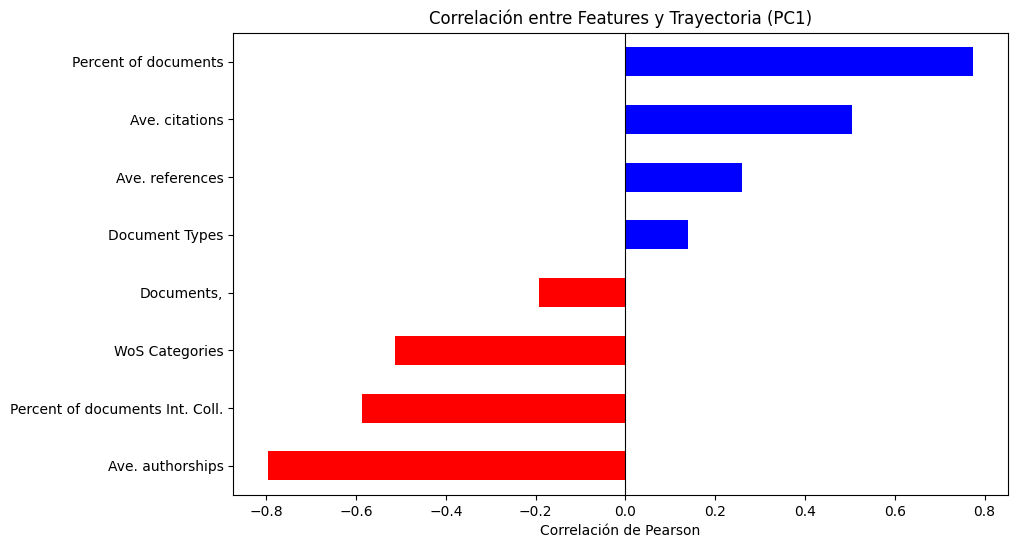

In [118]:
nombres_features = [f[1] for f in global_cfg.FEATURES]
df_features = eanalysis.obtener_promedios_anuales(df_flujo['year'].values, nombres_features, global_cfg.DATA_FOLDER)
df_flujo, correlaciones = eanalysis.correlacionar_y_alinear(df_flujo, df_features, ecfg.ALIGN_PC1_ANCHOR)

eviz.plot_correlaciones_barras(correlaciones)

In [119]:
print(df_features)

      WoS Categories  Document Types  Documents,  Ave. citations  \
1980        3.485437        1.436893    5.058252       48.737379   
1981        3.694444        1.555556    4.958333      199.423472   
1982        4.156250        1.546875    6.625000       31.289844   
1983        4.125000        1.480769    7.346154       51.024327   
1984        3.513158        1.394737    4.894737       42.550000   
1985        4.408696        1.565217    7.739130       40.570087   
1986        4.950166        1.687708    7.581395       24.748538   
1987        4.734300        1.589372    9.990338       27.244976   
1988        4.996942        1.782875    8.428135       30.477951   
1989        4.496032        1.547619    6.357143       26.825833   
1990        4.985994        1.697479   10.232493       33.543866   
1991        4.756667        1.600000    6.900000       29.553033   
1992        5.306452        1.698157    9.721198       20.961682   
1993        4.471154        1.634615    8.592949

In [120]:
#Percent of documents resultó  tener una correlación bastante alta, por lo tanto, las gráficas
#deberían ser bastante parecidas (la generada por pca y la que es a partir de los datos crudos)
#"Ave. authorships"
# 5. Gráficas de Comparación
df_plot, df_comparacion = eanalysis.preparar_datos_comparacion(df_features, df_flujo)
eviz.plot_feature_individual(df_plot, "Ave. authorships")
eviz.plot_comparacion_normalizada(df_comparacion)

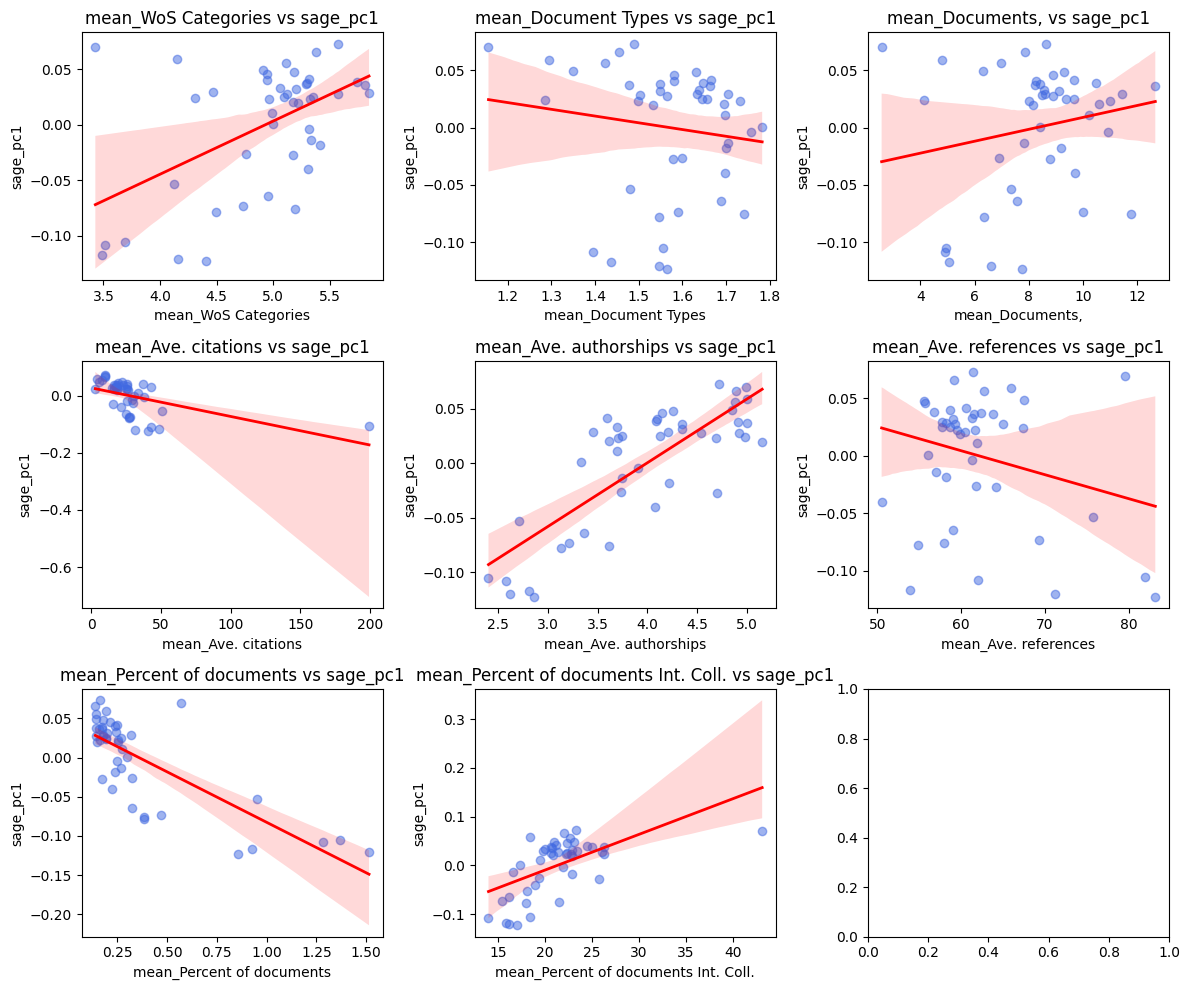

In [121]:
df_all = stat_analysis.cargar_y_unir_datos(cfg.LEVEL) #cargamos y preparamos los datos
#Exploración visual inicial
stat_viz.plot_dispersion_ols(df_all, 'mean_Percent of documents', 'sage_pc1')
# Los candidatos son exactamente los features definidos para hacer el embedding de sage
features_candidatas = [f"mean_{tupla[1]}" for tupla in global_cfg.FEATURES] # Extraemos el segundo elemento de la tupla (tupla[1]) y le pegamos "mean_"
stat_viz.plot_matriz_features(df_all, features_candidatas)

In [122]:
# Modelos OLS
# Múltiple sin HAC
modelo_mult = stat_analysis.ajustar_modelo_ols(df_all, 'sage_pc1', ['mean_Percent of documents', 'mean_Ave. citations', "mean_Ave. authorships"])
print(modelo_mult.summary())


#y = df_all['sage_pc1']  #variable objetivo
#X = df_all[['mean_Percent of documents', 'mean_Ave. authorships']] #Variables predictoras

# Le ponemos su constante 
#Ecuacion lineal de la forma y=b0 + b1x1 + b2x2 donde los xn son los atributos
#X = sm.add_constant(X) #cada atributo definido en X es un valor asociado a x_n, b0 es la constante (lo definimos como 1), b1 y b2 son los valores a estimar
#modelo = sm.OLS(y, X).fit()
#print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:               sage_pc1   R-squared:                       0.705
Model:                            OLS   Adj. R-squared:                  0.684
Method:                 Least Squares   F-statistic:                     32.68
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           5.92e-11
Time:                        18:49:05   Log-Likelihood:                 93.534
No. Observations:                  45   AIC:                            -179.1
Df Residuals:                      41   BIC:                            -171.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [123]:

# Múltiple sin HAC

modelo_mult = stat_analysis.ajustar_modelo_ols(df_all, 'sage_pc1', ['mean_Percent of documents', 'mean_Ave. authorships', 'mean_WoS Categories',
                                                                    'mean_Document Types', 'mean_Documents,','mean_Ave. citations',
                                                                    'mean_Ave. references','mean_Percent of documents Int. Coll.'])
print(modelo_mult.summary())


                            OLS Regression Results                            
Dep. Variable:               sage_pc1   R-squared:                       0.757
Model:                            OLS   Adj. R-squared:                  0.703
Method:                 Least Squares   F-statistic:                     14.04
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           5.22e-09
Time:                        18:49:05   Log-Likelihood:                 97.908
No. Observations:                  45   AIC:                            -177.8
Df Residuals:                      36   BIC:                            -161.6
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


In [124]:
# Simple con HAC
modelo_simple = stat_analysis.ajustar_modelo_ols(df_all, 'sage_pc1', ['mean_Ave. authorships'], usar_hac=True, maxlags=3)
print(modelo_simple.summary())
#mean_Percent of documents

                            OLS Regression Results                            
Dep. Variable:               sage_pc1   R-squared:                       0.633
Model:                            OLS   Adj. R-squared:                  0.624
Method:                 Least Squares   F-statistic:                     59.19
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           1.29e-09
Time:                        18:49:05   Log-Likelihood:                 88.607
No. Observations:                  45   AIC:                            -173.2
Df Residuals:                      43   BIC:                            -169.6
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -0.23

------------------------------------------------------------
Diagnostico de residuos
------------------------------------------------------------
Prueba de Durbin-Watson (Independencia): 1.346
Prueba de Shapiro-Wilk (Normalidad): p-value = 0.0055
Prueba de Breusch-Pagan (Homocedasticidad): p-value = 0.3216


/home/jose/miniconda3/envs/pateaAbuelitas/lib/python3.10/site-packages/statsmodels/graphics/gofplots.py:1041: UserWarning:

color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.



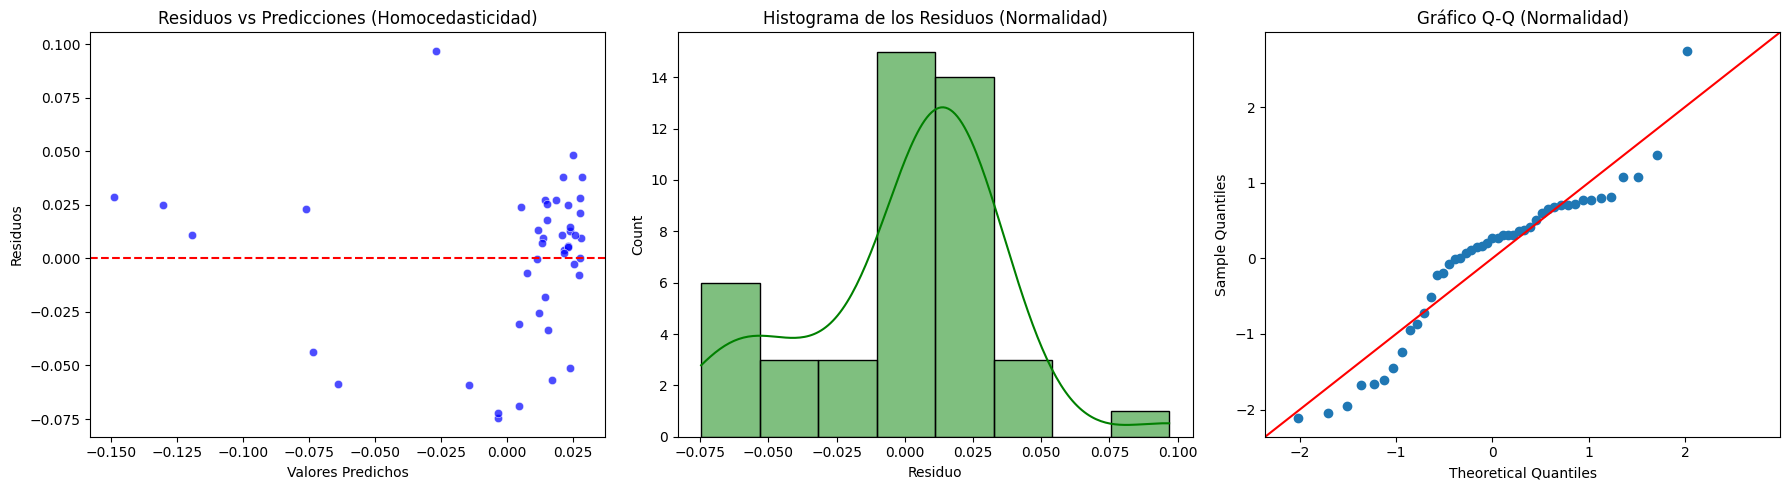

In [125]:
# Diagnóstico de residuos (del modelo simple normal para ver los errores puros)
modelo_base = stat_analysis.ajustar_modelo_ols(df_all, 'sage_pc1', ['mean_Percent of documents'])
residuos, predicciones = stat_analysis.ejecutar_diagnostico_residuos(modelo_base)

stat_viz.plot_panel_residuos(predicciones, residuos)
#stat_viz.plot_acf_residuos(df_all, residuos)

In [126]:
modelo_multiple = stat_analysis.ajustar_modelo_ols(
    df_all, 
    'sage_pc1', 
    ['mean_Percent of documents', 'mean_Ave. authorships'], 
    usar_hac=True, 
    maxlags=3
)
print(modelo_multiple.summary())

                            OLS Regression Results                            
Dep. Variable:               sage_pc1   R-squared:                       0.701
Model:                            OLS   Adj. R-squared:                  0.687
Method:                 Least Squares   F-statistic:                     95.01
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           2.58e-16
Time:                        18:49:06   Log-Likelihood:                 93.247
No. Observations:                  45   AIC:                            -180.5
Df Residuals:                      42   BIC:                            -175.1
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

  EXPERIMENTO E1: PCA sobre promedios bibliométricos directos

─────────────────────────────────────────────────────────────────
  Paso 1: PCA(mean(X_biblio) por año) → PC1_raw
─────────────────────────────────────────────────────────────────
[E1] Se invirtió PC1_raw para alinearlo con 'Percent of documents'. Corr original: -0.8981

  Varianza explicada por PC1_raw (EV1): 0.4595
  Features usadas: ['WoS Categories', 'Document Types', 'Documents,', 'Ave. citations', 'Ave. authorships', 'Ave. references', 'Percent of documents', 'Percent of documents Int. Coll.']
  Loadings de PC1_raw:
    WoS Categories                     : -0.4789
    Document Types                     : -0.2435
    Documents,                         : -0.3797
    Ave. citations                     : +0.3320
    Ave. authorships                   : -0.3132
    Ave. references                    : +0.3593
    Percent of documents               : +0.4684
    Percent of documents Int. Coll.    : -0.1019

────────────────

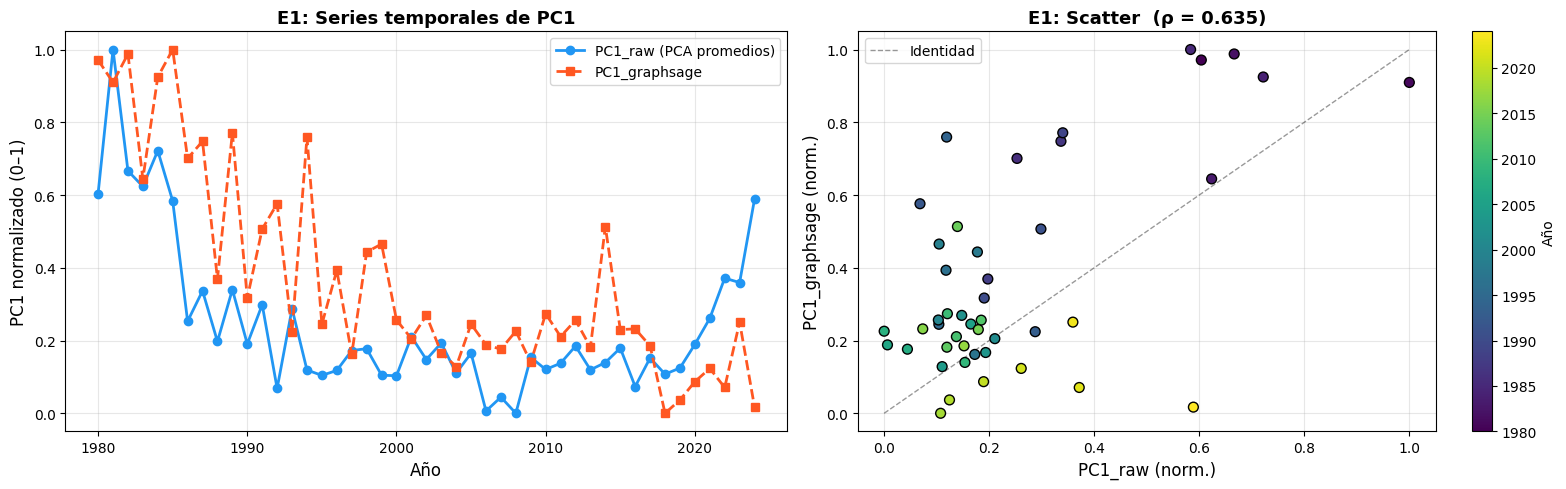

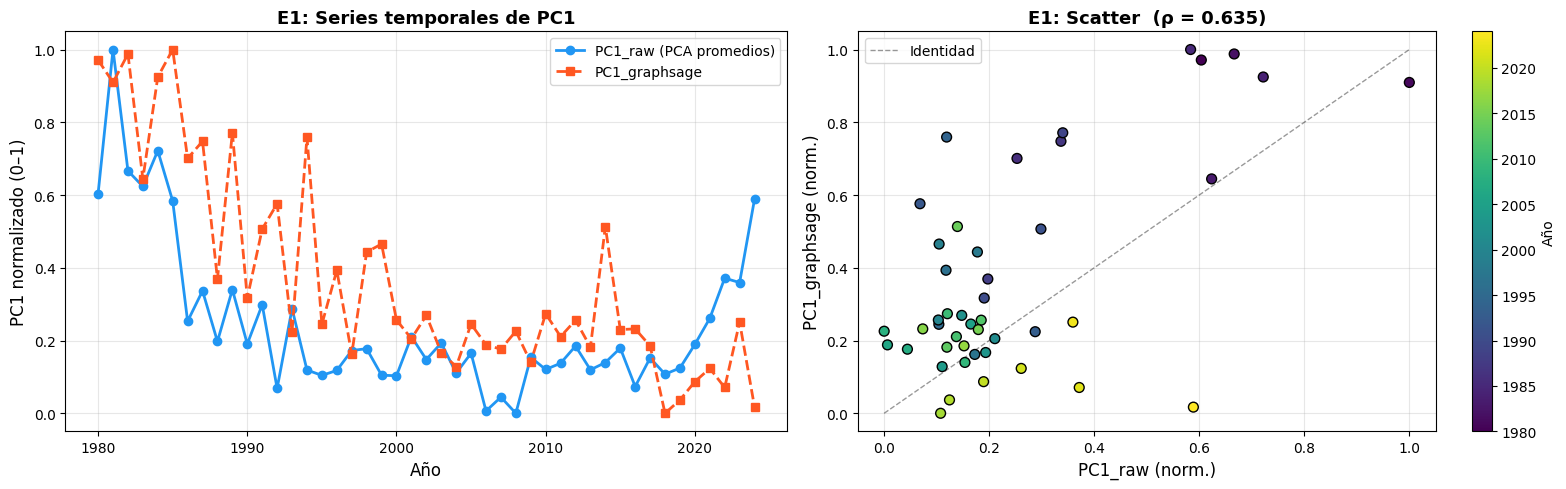

In [127]:
from src.baselines.e1_pca_promedios import ejecutar_e1
from src.baselines.visualization import plot_comparacion_pc1

# Ejecutar E1 completo (PCA sobre promedios → comparar con PC1 de GraphSAGE)
reporte_e1 = ejecutar_e1(df_features, df_flujo)

# Visualizar la comparación
plot_comparacion_pc1(reporte_e1["df_merged"])
